In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"

df = pd.read_csv(url)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [3]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [4]:
pd.crosstab(df['OverTime'], df['Attrition'])

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


In [2]:
import pandas as pd

In [5]:
import os
os.listdir('/content')

['.config', 'sample_data']

In [7]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [8]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

In [9]:
!kaggle datasets list -s "IBM HR Analytics Employee Attrition"

ref                                                                     title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
pavansubhasht/ibm-hr-analytics-attrition-dataset                        IBM HR Analytics Employee Attrition & Performance        51314  2017-03-31 06:55:16.973000         368869       3200  0.88235295       
kapoorprakhar/ibm-hr-analytics-employee-attrition-enhanced              IBM HR Analytics Employee Attrition (Enhanced)           57161  2026-08-22 09:32:06.720000            338          9  1                
uniabhi/ibm-hr-analytics-employee-attrition-performance                 IBM HR Analytics Employee Attrition & Performance        51314  2021-09-08 20:18:29.250000      

In [10]:
!kaggle datasets download -d pavansubhasht/ibm-hr-analytics-attrition-dataset

Dataset URL: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
License(s): DbCL-1.0
100% 50.1k/50.1k [00:00<00:00, 45.1MB/s]



In [11]:
!unzip -o ibm-hr-analytics-attrition-dataset.zip

Archive:  ibm-hr-analytics-attrition-dataset.zip
  inflating: WA_Fn-UseC_-HR-Employee-Attrition.csv  


In [12]:
import pandas as pd

df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [14]:
df.shape

(1470, 35)

In [15]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [16]:
pd.crosstab(df['OverTime'], df['Attrition'])

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


In [17]:
overtime_attrition = pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
) * 100

overtime_attrition.round(2)

Attrition,No,Yes
OverTime,,
No,89.56,10.44
Yes,69.47,30.53


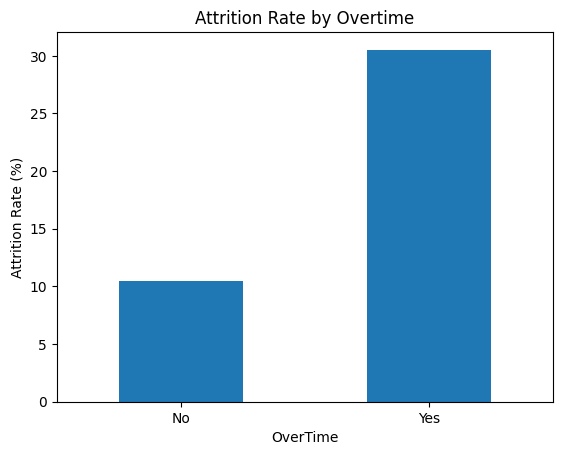

In [18]:
import matplotlib.pyplot as plt

attrition_rate = (
    df.groupby('OverTime')['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
)

attrition_rate.plot(kind='bar')

plt.title('Attrition Rate by Overtime')
plt.xlabel('OverTime')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [19]:
df.groupby('JobRole')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)

,Attrition
JobRole,
Sales Representative,39.759036
Laboratory Technician,23.938224
Human Resources,23.076923
Sales Executive,17.484663
Research Scientist,16.095890
Manufacturing Director,6.896552
Healthcare Representative,6.870229
Manager,4.901961
Research Director,2.500000


In [20]:
df.groupby('JobSatisfaction')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

,Attrition
JobSatisfaction,
1,22.837370
2,16.428571
3,16.515837
4,11.328976


In [21]:
df.groupby('Attrition')['MonthlyIncome'].mean()

,MonthlyIncome
Attrition,
No,6832.739659
Yes,4787.092827


In [22]:
df.groupby('Attrition')['YearsAtCompany'].mean()

,YearsAtCompany
Attrition,
No,7.369019
Yes,5.130802


In [23]:
df.groupby(['OverTime', 'JobSatisfaction'])['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

OverTime  JobSatisfaction
No        1                  17.560976
          2                   9.478673
          3                   9.968847
          4                   6.940063
Yes       1                  35.714286
          2                  37.681159
          3                  33.884298
          4                  21.126761
Name: Attrition, dtype: float64

In [24]:
pd.crosstab(df['OverTime'], df['Attrition'])

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


In [25]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['OverTime'], df['Attrition'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 87.56429365828768
p-value: 8.15842372153832e-21
Degrees of freedom: 1


In [26]:
import numpy as np

n = table.sum().sum()

cramers_v = np.sqrt(chi2 / n)

print("Cramer's V:", cramers_v)

Cramer's V: 0.24406463632881792


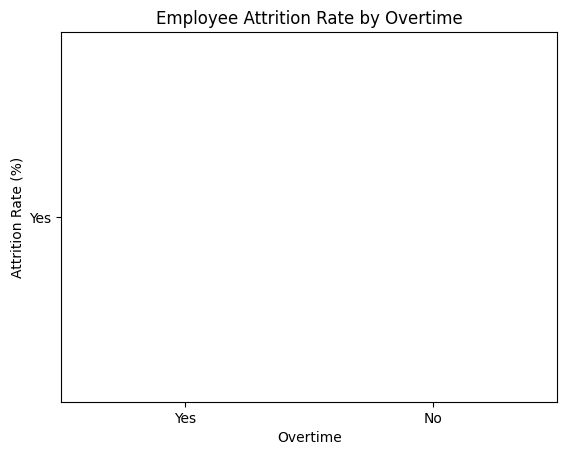

In [27]:


import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=df,
    x='OverTime',
    y='Attrition',
    estimator=lambda x: (x == 'Yes').mean() * 100
)

plt.title('Employee Attrition Rate by Overtime')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
plt.show()

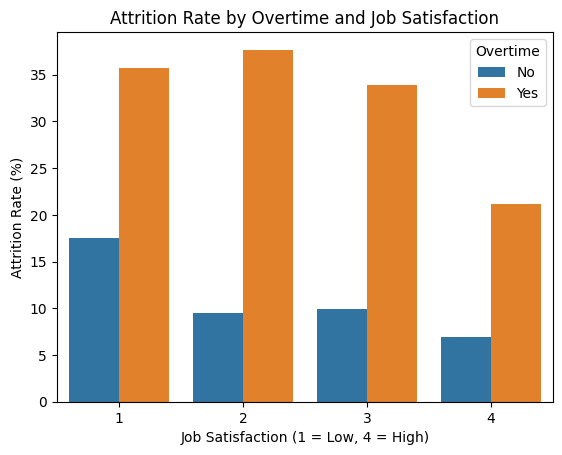

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_data = df.groupby(['OverTime', 'JobSatisfaction'])['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index(name='AttritionRate')

sns.barplot(
    data=plot_data,
    x='JobSatisfaction',
    y='AttritionRate',
    hue='OverTime'
)

plt.title('Attrition Rate by Overtime and Job Satisfaction')
plt.xlabel('Job Satisfaction (1 = Low, 4 = High)')
plt.ylabel('Attrition Rate (%)')
plt.legend(title='Overtime')
plt.show()

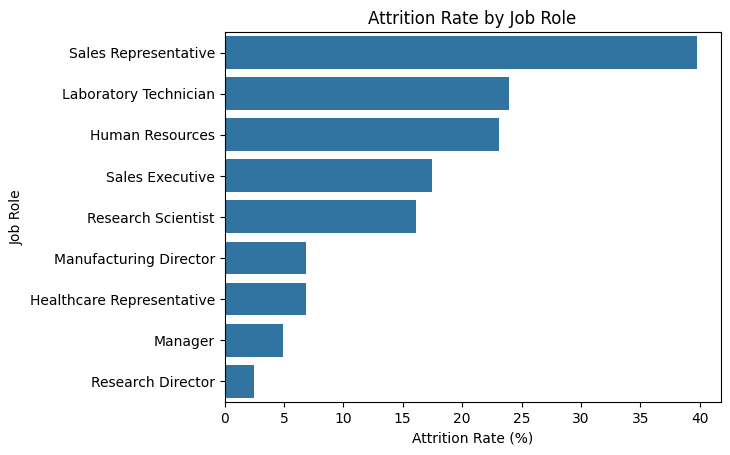

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

role_attrition = (
    df.groupby('JobRole')['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .sort_values(ascending=False)
      .reset_index(name='AttritionRate')
)

sns.barplot(
    data=role_attrition,
    x='AttritionRate',
    y='JobRole'
)

plt.title('Attrition Rate by Job Role')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
plt.show()

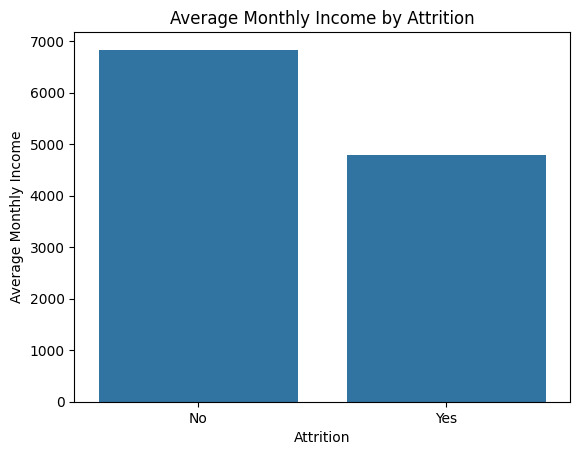

In [30]:
income_data = df.groupby('Attrition')['MonthlyIncome'].mean().reset_index()

sns.barplot(
    data=income_data,
    x='Attrition',
    y='MonthlyIncome'
)

plt.title('Average Monthly Income by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Average Monthly Income')
plt.show()

# Exploratory Data Analysis with a Finding

## IBM HR Analytics – Employee Attrition

### Project Objective

To explore employee data and identify an important factor associated with employee attrition.

### Main Finding

Employees who work overtime have substantially higher attrition rates than employees who do not work overtime.

### Tools Used

* Python
* Google Colab
* Pandas
* NumPy
* Matplotlib
* Seaborn
* SciPy


## Dataset Description

The dataset used for this project is the **IBM HR Analytics – Employee Attrition Dataset**.

It contains information about **1,470 employees** and **35 columns**. The dataset includes employee details such as:

* Age
* Gender
* Department
* Job Role
* Job Satisfaction
* Monthly Income
* Years at Company
* Overtime
* Work Environment Satisfaction
* Attrition

The main target variable is **Attrition**, which indicates whether an employee left the company or stayed.

* **No** → Employee stayed
* **Yes** → Employee left

The dataset contains **1,233 employees who stayed** and **237 employees who left**.


## Methodology

The following steps were followed to analyze the employee attrition dataset:

1. **Data Loading** – The IBM HR Analytics dataset was loaded into Google Colab using Python and Pandas.

2. **Data Understanding** – The dataset was examined to understand its rows, columns, data types, and employee-related variables.

3. **Exploratory Data Analysis** – Different factors were analyzed to understand their relationship with employee attrition.

4. **Visualization** – Bar charts were used to identify patterns and compare attrition rates across different employee groups.

5. **Statistical Analysis** – A Chi-square test and Cramér's V were used to statistically evaluate the association between overtime and employee attrition.

6. **Finding Identification** – The analysis identified overtime as an important factor associated with employee attrition.

7. **Recommendations** – Based on the findings, practical recommendations were developed for stakeholders.


## Exploratory Data Analysis Findings

### 1. Overtime and Employee Attrition

Employees working overtime showed a much higher attrition rate than employees who did not work overtime.

* **Overtime = No:** 10.44% attrition
* **Overtime = Yes:** 30.53% attrition

This shows that employees working overtime had nearly **3 times higher attrition** than employees who did not work overtime.

### 2. Job Role and Attrition

Attrition rates differed across job roles.

* **Sales Representatives:** 39.76% – highest attrition
* **Laboratory Technicians:** 23.94%
* **Human Resources:** 23.08%
* **Research Directors:** 2.50% – lowest attrition

This indicates that employee attrition varies considerably across different job roles.

### 3. Job Satisfaction and Attrition

Employees with lower job satisfaction generally showed higher attrition.

* **Satisfaction 1:** 22.84%
* **Satisfaction 2:** 16.43%
* **Satisfaction 3:** 16.52%
* **Satisfaction 4:** 11.33%

Employees with the lowest satisfaction level had about twice the attrition rate of employees with the highest satisfaction level.

### 4. Monthly Income and Attrition

The average monthly income was different between employees who stayed and those who left.

* **Employees who stayed:** ₹6,832.74
* **Employees who left:** ₹4,787.09

Employees who left had an average monthly income about **₹2,045 lower** than employees who stayed.

### 5. Years at Company and Attrition

Employees who stayed had been with the company longer on average.

* **Employees who stayed:** 7.37 years
* **Employees who left:** 5.13 years

This suggests that shorter tenure is associated with higher employee attrition.


## Main Finding

### Overtime is Strongly Associated with Employee Attrition

The analysis found that employees who work overtime have a substantially higher attrition rate than employees who do not work overtime.

| Overtime | Attrition Rate |
| -------- | -------------: |
| No       |         10.44% |
| Yes      |         30.53% |

Employees working overtime had nearly **3 times higher attrition** than employees who did not work overtime.

### Statistical Validation

A **Chi-square test of independence** was performed to determine whether overtime and employee attrition were statistically associated.

* **Chi-square statistic:** 87.56
* **p-value:** < 0.001
* **Cramér's V:** 0.244

Since the p-value is much smaller than 0.05, the relationship between overtime and attrition is **statistically significant**.

Cramér's V of **0.244** indicates a **small-to-moderate association** between overtime and employee attrition.

Therefore, the analysis provides strong evidence that **overtime is significantly associated with employee attrition**.

> Note: This analysis identifies an association. It does not prove that overtime directly causes employees to leave.


## Main Finding

### Overtime is Strongly Associated with Employee Attrition

The analysis found that employees who work overtime have a substantially higher attrition rate than employees who do not work overtime.

| Overtime | Attrition Rate |
| -------- | -------------: |
| No       |         10.44% |
| Yes      |         30.53% |

Employees working overtime had nearly **3 times higher attrition** than employees who did not work overtime.

### Statistical Validation

A **Chi-square test of independence** was performed to determine whether overtime and employee attrition were statistically associated.

* **Chi-square statistic:** 87.56
* **p-value:** < 0.001
* **Cramér's V:** 0.244

Since the p-value is much smaller than 0.05, the relationship between overtime and attrition is **statistically significant**.

Cramér's V of **0.244** indicates a **small-to-moderate association** between overtime and employee attrition.

Therefore, the analysis provides strong evidence that **overtime is significantly associated with employee attrition**.

> Note: This analysis identifies an association. It does not prove that overtime directly causes employees to leave.


## Main Finding

### Overtime is Strongly Associated with Employee Attrition

The analysis found that employees who work overtime have a substantially higher attrition rate than employees who do not work overtime.

| Overtime | Attrition Rate |
| -------- | -------------: |
| No       |         10.44% |
| Yes      |         30.53% |

Employees working overtime had nearly **3 times higher attrition** than employees who did not work overtime.

### Statistical Validation

A **Chi-square test of independence** was performed to determine whether overtime and employee attrition were statistically associated.

* **Chi-square statistic:** 87.56
* **p-value:** < 0.001
* **Cramér's V:** 0.244

Since the p-value is much smaller than 0.05, the relationship between overtime and attrition is **statistically significant**.

Cramér's V of **0.244** indicates a **small-to-moderate association** between overtime and employee attrition.

Therefore, the analysis provides strong evidence that **overtime is significantly associated with employee attrition**.

> Note: This analysis identifies an association. It does not prove that overtime directly causes employees to leave.


## Stakeholder Recommendations

Based on the analysis, the following recommendations can be made:

1. **Monitor Overtime**

   * Regularly track employees and teams with high overtime levels.
   * Identify departments where overtime is consistently high.

2. **Improve Work-Life Balance**

   * Review workloads and working hours for employees frequently working overtime.
   * Consider better workload distribution where possible.

3. **Focus on High-Risk Groups**

   * Pay special attention to employees with high overtime and low job satisfaction.
   * Conduct regular employee feedback and engagement surveys.

4. **Support High-Attrition Job Roles**

   * Investigate the reasons for high attrition in roles such as Sales Representative.
   * Review workload, career growth opportunities, and employee support in these roles.

5. **Strengthen Employee Retention**

   * Provide career development opportunities and regular feedback.
   * Use employee attrition data to identify groups that may require additional retention efforts.

### Business Impact

Reducing excessive overtime and improving employee support may help organizations identify and address factors associated with employee turnover.


## Conclusion

This exploratory data analysis examined the IBM HR Analytics Employee Attrition dataset containing **1,470 employees**.

The analysis explored different factors associated with employee attrition, including overtime, job role, job satisfaction, monthly income, and years at the company.

The most important finding was that **employees who work overtime have a substantially higher attrition rate (30.53%) compared with employees who do not work overtime (10.44%)**.

The Chi-square test confirmed that the relationship between overtime and attrition is statistically significant (**χ² = 87.56, p < 0.001**). The Cramér's V value of **0.244** indicates a small-to-moderate association.

Overall, this analysis provides useful insights that can help stakeholders identify employee groups with higher attrition risk and consider strategies to improve employee retention.

### Final Finding

**Overtime is significantly associated with higher employee attrition and should be considered an important factor when analyzing employee retention.**
